In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

In [2]:
X, y = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)

In [3]:
X = StandardScaler().fit_transform(X)

In [4]:
lof = LocalOutlierFactor(n_neighbors=25, contamination=0.1,metric = 'euclidean', novelty=False)
y_pred = lof.fit_predict(X)

In [5]:
outliers = y_pred == -1

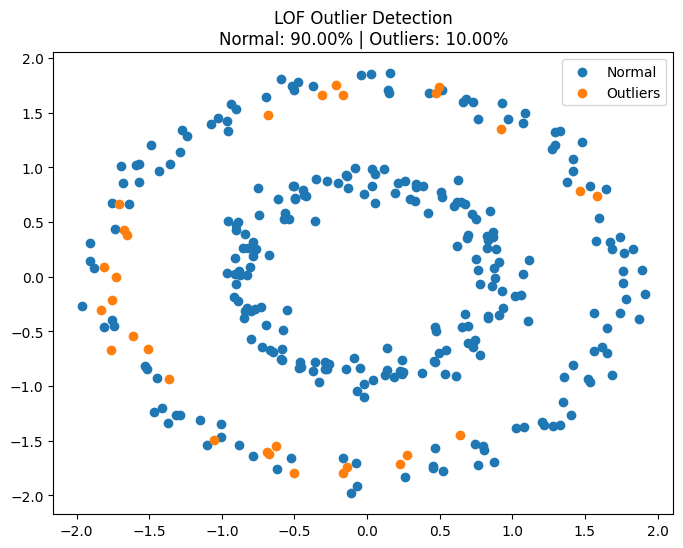

In [6]:
total = len(y_pred)
outlier_pct = np.sum(outliers) / total * 100
normal_pct = 100 - outlier_pct

plt.figure(figsize=(8,6))
plt.scatter(X[~outliers, 0], X[~outliers, 1], label='Normal')
plt.scatter(X[outliers, 0], X[outliers, 1], label='Outliers')

plt.title(f"LOF Outlier Detection\nNormal: {normal_pct:.2f}% | Outliers: {outlier_pct:.2f}%")
plt.legend()
plt.show()